# 05: The East-West NDE Dichotomy — Testing Cultural Paradigm Claims

**Purpose:** Test the prevalence claims of the "Western" NDE profile (personified Being of Light, Cities of Light, frequent life reviews, tunnel) against 6,751 structured accounts from NDERF and IANDS; examine what predicts personal interaction with the Light ("purposive economy"); and examine what boundary ("point of no return") reports correspond to.

**Schema:** 2026-01-06 · **Audited and corrected:** 2026-10-05

**Scope limits.** (1) The archives are predominantly but not exclusively Western/English-language; country is unknown for most accounts (Part 0). (2) No Japanese sample is analysed here, so claims about the Japanese profile cannot be tested. (3) The literature figures quoted as "claimed Western rates" (70–80%, 25–30%, 34–50%) are taken as stated in the source document `docs/The Universal Light and the Cultural Lens_…md`; their original denominators (e.g. % of all NDEs vs % of deep NDEs) are not documented, which limits any comparison.

## Audit corrections (2026-10-05)

| # | Problem in previous version | Effect | Fix |
|---|---|---|---|
| 1 | Cells 22–46 re-ran the whole analysis against a **legacy schema** (`r['environment']`, `r['beings_encountered']`, …) | Every metric 0.0%; two `ZeroDivisionError`s; tables reported "Being of Light 0.0%", "Life review 0.0%" with binomial p = 0 | Duplicate section removed |
| 2 | "Being of Light" detected by searching `'light'` in `being_identifications`; Jesus/God searched in `spiritual_beings` | Being of Light 0.0%, Jesus/God 0.0% in the first summary | `light_encounter == being_of_light`; identifications read from `being_identifications` |
| 3 | "Religious figures" = `religious_figure_specified` OR `guides_or_angels` (God and Jesus omitted) | 9.9%, so "deceased relatives (17.9%) nearly twice religious figures" | Correct counts 13.8% (named figures) to 19.9% (incl. angels/spiritual-being codes) — the "inversion" depends on definition |
| 4 | Life review tested against `'yes'/'partial'` (schema: `brief/extensive`) | 0.0% in the first summary | Fixed (17.5%) |
| 5 | Nature vs urban tested with a goodness-of-fit χ² on **overlapping** counts | Invalid test | McNemar test on paired indicators |
| 6 | Hard-coded results table (cell 59) and Jesus/God percentages double-counting cases with both | 53.1% / 10.4% | Computed from data (union) |
| 7 | Appendix χ² values inconsistent with their p-values (e.g. "χ² = 53.2, p < 10⁻³⁰") | — | Recomputed |
| 8 | Text claimed tunnel and boundary are "statistically independent" / "r = −0.02" | Contradicted by the notebook's own OR = 2.43 | Corrected |
| 9 | Depth score counted life review with `'yes_explicit'` and a non-existent `knowledge_received` field | Depth score missing two components | Fixed |
| 10 | "Brilliant light" relabelled "impersonal" | The field means "light without an identified being *of* light", not "no personal interaction" — 57% of these accounts identify beings and 67% report communication | Relabelled; interaction measured directly |
| 11 | No control for narrative length (richer accounts mention more of everything) | Co-occurrence ratios inflated | Length-adjusted odds ratios |

## Setup

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())


ids = df["being_identifications"]
df["named_religious_figure"] = nd.isin(df, "being_identifications", nd.RELIGIOUS_FIGURE_IDS)
df["angels_id"] = nd.has(df, "being_identifications", "angels")
df["deceased"] = nd.isin(df, "deceased_relatives", nd.DECEASED_YES)
df["tunnel"] = df["passage_type"] == "tunnel"
df["landscape"] = nd.has(df, "environment_features", "landscape")
df["buildings"] = nd.has(df, "environment_features", "buildings")
df["water"] = nd.has(df, "environment_features", "water")
df["heavenly"] = nd.has(df, "realm_types", "heavenly")
df["earthly_mission"] = nd.has(df, "return_reasons", "earthly_mission")
df["any_comm"] = df["communication_modes"].apply(lambda ms: bool(set(ms) - {"no_communication", "not_specified"}))

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092


---
## Part 0: How "Western" is the sample?

In [2]:
country = df["location_country"].fillna("not_mentioned").replace({"USA": "United States", "UK": "United Kingdom", "England": "United Kingdom", "Scotland": "United Kingdom"})
known = country[country != "not_mentioned"]
print(f"Country stated: {nd.fmt_pct(len(known), N)}")
print(known.value_counts().head(15).to_string())
western = {"United States", "Canada", "United Kingdom", "Australia", "New Zealand", "Ireland", "France", "Germany", "Spain", "Italy",
           "Netherlands", "Belgium", "Sweden", "Norway", "Denmark", "Finland", "Switzerland", "Austria", "Portugal"}
print(f"\nOf accounts with a country, North America/Western Europe/Australasia: {nd.fmt_pct(int(known.isin(western).sum()), len(known))}")

Country stated: 829/6751 = 12.3% [95% CI 11.5–13.1]
location_country
United States     355
Canada             53
United Kingdom     44
France             39
Australia          27
India              21
Germany            17
Mexico             15
Spain              15
Brazil             13
Italy              12
New Zealand         9
Iran                7
Colombia            7
Argentina           7

Of accounts with a country, North America/Western Europe/Australasia: 603/829 = 72.7% [95% CI 69.6–75.7]


Country is stated for only ~12% of accounts; among those, about 27% are from outside North America, Western Europe and Australasia (e.g. India, Mexico, Brazil, Iran). "Western NDEs" below therefore means *accounts in two predominantly Western, English-language archives*.

---
## Part I: The Being of Light paradigm

In [3]:
print("LIGHT ENCOUNTER (passage.arrival.light_encounter)")
for k, v in df["light_encounter"].value_counts().items():
    print(f"  {k:24s} {nd.fmt_pct(int(v), N)}")
bol = int(df["bol_encounter"].sum())
stated = int((df["light_encounter"] != "not_mentioned").sum())
any_light = int(df["light_encounter"].isin(["being_of_light", "brilliant_light", "presence_without_visual"]).sum())
print(f"\nBeing of Light: {nd.fmt_pct(bol, N)} of all; {nd.fmt_pct(bol, stated)} of accounts addressing light; {nd.fmt_pct(bol, any_light)} of accounts with any light/presence")

br = df[df["light_encounter"] == "brilliant_light"]
print(f"\nWhat 'brilliant_light' accounts contain (n = {len(br)}):")
print(f"  any being identified:          {nd.fmt_pct(int((br.being_identifications.apply(len) > 0).sum()), len(br))}")
print(f"  God or Jesus identified:       {nd.fmt_pct(int(nd.isin(br, 'being_identifications', ['god','jesus']).sum()), len(br))}")
print(f"  communication with beings:     {nd.fmt_pct(int(br.any_comm.sum()), len(br))}")
print(f"  telepathic communication:      {nd.fmt_pct(int(nd.has(br, 'communication_modes', 'telepathic').sum()), len(br))}")
b = df[df["bol_encounter"]]
print(f"\nFor comparison, 'being_of_light' accounts (n = {len(b)}): God or Jesus {nd.fmt_pct(int(nd.isin(b, 'being_identifications', ['god','jesus']).sum()), len(b))}; communication {nd.fmt_pct(int(b.any_comm.sum()), len(b))}")

LIGHT ENCOUNTER (passage.arrival.light_encounter)
  brilliant_light          2759/6751 = 40.9% [95% CI 39.7–42.0]
  no                       1636/6751 = 24.2% [95% CI 23.2–25.3]
  not_mentioned            1274/6751 = 18.9% [95% CI 18.0–19.8]
  being_of_light           797/6751 = 11.8% [95% CI 11.1–12.6]
  presence_without_visual  285/6751 = 4.2% [95% CI 3.8–4.7]

Being of Light: 797/6751 = 11.8% [95% CI 11.1–12.6] of all; 797/5477 = 14.6% [95% CI 13.6–15.5] of accounts addressing light; 797/3841 = 20.7% [95% CI 19.5–22.1] of accounts with any light/presence

What 'brilliant_light' accounts contain (n = 2759):
  any being identified:          1574/2759 = 57.0% [95% CI 55.2–58.9]
  God or Jesus identified:       201/2759 = 7.3% [95% CI 6.4–8.3]
  communication with beings:     1570/2759 = 56.9% [95% CI 55.0–58.7]
  telepathic communication:      707/2759 = 25.6% [95% CI 24.0–27.3]

For comparison, 'being_of_light' accounts (n = 797): God or Jesus 370/797 = 46.4% [95% CI 43.0–49.9]; commu

**Finding (statistically supported):** the light itself is coded as a *being* in 11.8% of all accounts (14.6% of those that address light; 20.7% of those reporting any light or presence). Brilliant light without a being *of* light is about 3.5× more common.

**Correction:** "brilliant light" is **not** the same as "impersonal". More than half of brilliant-light accounts identify beings and two-thirds report communication with beings. The previous "impersonal : personified = 3.8 : 1" therefore compares *the form of the light*, not *personal vs impersonal encounters*.

In [4]:
print("BEING IDENTIFICATIONS (% of all NDEs; multi-select)")
for k, v in Counter(b for bs in ids for b in bs).most_common():
    print(f"  {k:28s} {nd.fmt_pct(v, N)}")

print("\nRELIGIOUS FIGURES vs DECEASED RELATIVES — the comparison depends on the definition")
from statsmodels.stats.contingency_tables import mcnemar
definitions = {
    "named religious figure (God/Jesus/Buddha/specified)": df.named_religious_figure,
    "named religious figure or angels (identifications)": df.named_religious_figure | df.angels_id,
    "… or spiritual_beings: religious_figures / guides_or_angels": df.named_religious_figure | df.angels_id
        | nd.isin(df, "spiritual_beings", ["religious_figures", "guides_or_angels"]),
}
print(f"  Deceased relatives (deceased_relatives named/unnamed): {nd.fmt_pct(int(df.deceased.sum()), N)}")
for label, rf in definitions.items():
    t = pd.crosstab(df.deceased, rf)
    res = mcnemar(t.values, exact=False, correction=True)
    print(f"  {label:62s} {nd.fmt_pct(int(rf.sum()), N)};  McNemar vs deceased χ² = {res.statistic:.1f}, p = {res.pvalue:.2g}")
nb_def = nd.has(df, "being_identifications", "religious_figure_specified") | nd.has(df, "spiritual_beings", "guides_or_angels")
print(f"  (previous definition, omitting God and Jesus: {int(nb_def.sum())} = {100*nb_def.mean():.1f}%)")

BEING IDENTIFICATIONS (% of all NDEs; multi-select)
  other                        1732/6751 = 25.7% [95% CI 24.6–26.7]
  deceased_relative_guide      1096/6751 = 16.2% [95% CI 15.4–17.1]
  unknown_presence             1049/6751 = 15.5% [95% CI 14.7–16.4]
  god                          499/6751 = 7.4% [95% CI 6.8–8.0]
  jesus                        399/6751 = 5.9% [95% CI 5.4–6.5]
  angels                       373/6751 = 5.5% [95% CI 5.0–6.1]
  religious_figure_specified   160/6751 = 2.4% [95% CI 2.0–2.8]
  buddha                       7/6751 = 0.1% [95% CI 0.1–0.2]

RELIGIOUS FIGURES vs DECEASED RELATIVES — the comparison depends on the definition
  Deceased relatives (deceased_relatives named/unnamed): 1206/6751 = 17.9% [95% CI 17.0–18.8]
  named religious figure (God/Jesus/Buddha/specified)            930/6751 = 13.8% [95% CI 13.0–14.6];  McNemar vs deceased χ² = 43.8, p = 3.7e-11
  named religious figure or angels (identifications)             1157/6751 = 17.1% [95% CI 16.3–18.1];

**Correction:** the previous "deceased relatives (17.9%) nearly twice religious figures (9.9%)" omitted God and Jesus. Correctly counted, *named* religious figures (13.8%) are less common than deceased relatives (17.9%), a ratio of 1.3, but religious figures **including angels** — the category label the report itself used ("God/Jesus/angels/specified") — are as common as or more common than deceased relatives (17.1–19.9%). The "ancestor model inversion" is therefore **definition-dependent and not supported** as stated.

---
## Part II: Environment, tunnel and boundary prevalence

In [5]:
print("ENVIRONMENT FEATURES (% of all NDEs)")
for k, v in Counter(f for fs in df["environment_features"] for f in fs).most_common():
    print(f"  {k:10s} {nd.fmt_pct(v, N)}")
t = pd.crosstab(df.landscape, df.buildings)
res = mcnemar(t.values, exact=False, correction=True)
print(f"\nLandscape vs buildings (paired): landscape {100*df.landscape.mean():.1f}%, buildings {100*df.buildings.mean():.1f}%; "
      f"both {int(t.loc[True, True])}; McNemar χ² = {res.statistic:.1f}, p = {res.pvalue:.2g}")
envd = nd.isin(df, "environment_environment_description", ["brief", "detailed"])
print(f"Among accounts describing an environment (n = {int(envd.sum())}): landscape {100*df.loc[envd,'landscape'].mean():.1f}%, buildings {100*df.loc[envd,'buildings'].mean():.1f}%")

print("\nPASSAGE TYPE")
for k, v in df["passage_type"].value_counts().items():
    print(f"  {k:14s} {nd.fmt_pct(int(v), N)}")
print("\nBOUNDARY ENCOUNTER")
for k, v in df["boundary_encounter"].value_counts().items():
    print(f"  {k:18s} {nd.fmt_pct(int(v), N)}")
print(f"  any boundary: {nd.fmt_pct(int(df.any_boundary.sum()), N)}")

ENVIRONMENT FEATURES (% of all NDEs)
  light      3394/6751 = 50.3% [95% CI 49.1–51.5]
  other      2741/6751 = 40.6% [95% CI 39.4–41.8]
  colors     1906/6751 = 28.2% [95% CI 27.2–29.3]
  landscape  1151/6751 = 17.0% [95% CI 16.2–18.0]
  sky        871/6751 = 12.9% [95% CI 12.1–13.7]
  buildings  772/6751 = 11.4% [95% CI 10.7–12.2]
  water      414/6751 = 6.1% [95% CI 5.6–6.7]

Landscape vs buildings (paired): landscape 17.0%, buildings 11.4%; both 296; McNemar χ² = 107.4, p = 3.7e-25
Among accounts describing an environment (n = 4998): landscape 23.0%, buildings 15.4%

PASSAGE TYPE
  no             3360/6751 = 49.8% [95% CI 48.6–51.0]
  tunnel         1602/6751 = 23.7% [95% CI 22.7–24.8]
  other          733/6751 = 10.9% [95% CI 10.1–11.6]
  void           537/6751 = 8.0% [95% CI 7.3–8.6]
  not_mentioned  519/6751 = 7.7% [95% CI 7.1–8.3]

BOUNDARY ENCOUNTER
  none               2789/6751 = 41.3% [95% CI 40.1–42.5]
  verbal_limit       1233/6751 = 18.3% [95% CI 17.4–19.2]
  not_mentio

**Finding (statistically supported):** landscape features are more common than buildings (17.0% vs 11.4%; McNemar p < 10⁻²⁰). The schema has no "garden" or "city" category, so "flower gardens vs Cities of Light" is approximated by *landscape* vs *buildings*. The tunnel appears in 23.7% of accounts.

---
## Part III: Life review

In [6]:
lr = df[df["life_review"]]
print(f"Life review: {nd.fmt_pct(len(lr), N)}  ({nd.fmt_pct(len(lr), int((df.occurrence!='not_mentioned').sum()))} of accounts addressing it)")
print(f"  brief {int((df.occurrence=='brief').sum())}, extensive {int((df.occurrence=='extensive').sum())}")
judged = lr[lr["judgment_source"].isin(["self", "being_of_light", "guide_or_entity", "deceased_relative"])]
print(f"Life reviews with a judgment element (any evaluator, including self): {nd.fmt_pct(len(judged), N)} of all NDEs")
print(f"Life reviews with an external evaluator (Being/guide/relative):     {nd.fmt_pct(int(judged.judgment_source.isin(['being_of_light','guide_or_entity','deceased_relative']).sum()), N)} of all NDEs")

Life review: 1183/6751 = 17.5% [95% CI 16.6–18.4]  (1183/6426 = 18.4% [95% CI 17.5–19.4] of accounts addressing it)
  brief 718, extensive 465
Life reviews with a judgment element (any evaluator, including self): 435/6751 = 6.4% [95% CI 5.9–7.1] of all NDEs
Life reviews with an external evaluator (Being/guide/relative):     340/6751 = 5.0% [95% CI 4.5–5.6] of all NDEs


In [7]:
print("CLAIMED vs OBSERVED RATES (exact binomial tests against the lower bound of each claim)")
rows = []
for feature, claimed, k, n in [("Being of Light (light_encounter)", 0.70, bol, N),
                               ("Being of Light, of accounts with any light", 0.70, bol, any_light),
                               ("Life review", 0.25, len(lr), N),
                               ("Tunnel", 0.34, int(df.tunnel.sum()), N)]:
    test = stats.binomtest(k, n, claimed)
    lo, hi = nd.wilson_ci(k, n)
    rows.append({"feature": feature, "claimed (lower bound)": f"{100*claimed:.0f}%", "observed": f"{100*k/n:.1f}%",
                 "95% CI": f"{100*lo:.1f}–{100*hi:.1f}", "n": n, "binomial p": f"{test.pvalue:.2g}"})
print(pd.DataFrame(rows).to_string(index=False))

CLAIMED vs OBSERVED RATES (exact binomial tests against the lower bound of each claim)
                                   feature claimed (lower bound) observed    95% CI    n binomial p
          Being of Light (light_encounter)                   70%    11.8% 11.1–12.6 6751          0
Being of Light, of accounts with any light                   70%    20.7% 19.5–22.1 3841          0
                               Life review                   25%    17.5% 16.6–18.4 6751    3.9e-49
                                    Tunnel                   34%    23.7% 22.7–24.8 6751    3.3e-75


**Finding:** all three "Western" prevalence claims exceed what these archives show — the Being of Light by a wide margin even on the most generous denominator (20.7% of accounts with any light vs a claimed 70–80%), the life review (17.5% vs 25–30%) and the tunnel (23.7% vs 34–50%) by smaller margins. Because the claimed figures' denominators are undocumented and these archives are self-selected, this shows that **the claimed rates do not describe these archives**; it does not by itself show how the claims arose.

---
## Part IV: What predicts personal interaction? ("purposive economy")

The hypothesis: the Light becomes personal when the encounter has a purpose (life review, mission). Each association is reported crude and **adjusted for narrative length**, since longer accounts report more of every element.

In [8]:
t = pd.crosstab(df["light_encounter"], df["life_review"])
print("Life review rate by light-encounter type:")
print((100 * t[True] / t.sum(axis=1)).round(1).to_string())
s = df[df.light_encounter.isin(["being_of_light", "brilliant_light", "presence_without_visual"])]
t2 = pd.crosstab(s.light_encounter, s.life_review)
chi2, p, dof, _ = chi2_contingency(t2)
print(f"χ² (3 light types × life review) = {chi2:.1f}, df = {dof}, p = {p:.2g}")

rows = []
for label, x in [("Life review", df.life_review), ("Earthly mission (reason)", df.earthly_mission),
                 ("Not your time (reason)", nd.has(df, "return_reasons", "not_your_time")),
                 ("Family responsibility (reason)", nd.has(df, "return_reasons", "family_responsibility")),
                 ("Mission commissioned", nd.isin(df, "mission_commissioned", nd.YES))]:
    tt = pd.crosstab(x, df.bol_encounter)
    chi2, p, dof, expected = chi2_contingency(tt)
    orr, fp = fisher_exact(tt)
    a = nd.adjusted_odds_ratio(df.assign(y=df.bol_encounter.astype(int), x=x.astype(int)), "y", "x")
    rows.append({"element": label, "co-occur": int(tt.loc[True, True]), "expected": round(expected[1, 1], 1),
                 "ratio": round(tt.loc[True, True] / expected[1, 1], 2), "χ² (Yates)": round(chi2, 1), "p": p,
                 "OR": round(orr, 2), "length-adj OR": round(a["adj_or"], 2), "adj 95% CI": f"{a['adj_ci'][0]:.2f}–{a['adj_ci'][1]:.2f}",
                 "BoL rate with": f"{100*df.bol_encounter[x].mean():.1f}%", "BoL rate without": f"{100*df.bol_encounter[~x].mean():.1f}%"})
purpose = pd.DataFrame(rows)
print(purpose.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

Life review rate by light-encounter type:
light_encounter
being_of_light             32.0
brilliant_light            19.1
no                         13.3
not_mentioned              10.5
presence_without_visual    17.5


χ² (3 light types × life review) = 64.0, df = 2, p = 1.3e-14


                       element  co-occur  expected  ratio  χ² (Yates)        p   OR  length-adj OR adj 95% CI BoL rate with BoL rate without
                   Life review       255       140   1.83         130 4.49e-30 2.55           1.89  1.59–2.25         21.6%             9.7%
      Earthly mission (reason)       200      73.5   2.72         269 1.52e-60 4.38           3.26  2.68–3.97         32.1%             9.7%
        Not your time (reason)       297       172   1.72         130 4.87e-30 2.45            2.3  1.96–2.70         20.4%             9.4%
Family responsibility (reason)       203       137   1.48        42.2 8.11e-11 1.78            1.5  1.25–1.79         17.4%            10.6%
          Mission commissioned       375       175   2.15         332 4.06e-74  3.9           2.88  2.45–3.39         25.3%             8.0%


In [9]:
print("Being of Light vs brilliant light — co-occurring elements")
b = df[df.bol_encounter]; br = df[df.light_encounter == "brilliant_light"]
rows = []
for label, f in [("life review", lambda d: d.life_review), ("earthly mission reason", lambda d: d.earthly_mission),
                 ("God or Jesus identified (union)", lambda d: nd.isin(d, "being_identifications", ["god", "jesus"])),
                 ("greeted by spiritual beings", lambda d: nd.has(d, "greeting_types", "spiritual_beings")),
                 ("any communication", lambda d: d.any_comm)]:
    rb, rr = f(b).mean(), f(br).mean()
    rows.append({"element": label, "being_of_light": f"{100*rb:.1f}%", "brilliant_light": f"{100*rr:.1f}%", "ratio": round(rb/rr, 2)})
print(pd.DataFrame(rows).to_string(index=False))

Being of Light vs brilliant light — co-occurring elements
                        element being_of_light brilliant_light  ratio
                    life review          32.0%           19.1%   1.68
         earthly mission reason          25.1%            9.5%   2.63
God or Jesus identified (union)          46.4%            7.3%   6.37
    greeted by spiritual beings          56.0%           12.8%   4.37
              any communication          88.8%           56.9%   1.56


**Findings.**
- *Statistically supported:* Being-of-Light encounters co-occur with life reviews, earthly-mission returns, and other return reasons more than chance predicts. The strongest is earthly mission (BoL in 32.1% vs 9.7%; OR 4.38, p ≈ 10⁻⁴⁶), and it **survives** adjustment for narrative length (adjusted OR ≈ 3.3).
- *Caveat:* these are co-occurrences within the same narrative coded by the same model; an encounter described as a luminous being giving instructions will naturally be coded both as `being_of_light` and as a mission. The association is real in the data; its direction ("purpose *calls forth* personal interaction") is **interpretation**.
- The previous table's "Jesus/God identified 53.1% vs 10.4%" double-counted cases with both and used a hard-coded denominator; computed values are above.

---
## Part V: Boundaries ("point of no return")

In [10]:
t = pd.crosstab(df.tunnel, df.any_boundary)
chi2, p, _, _ = chi2_contingency(t)
orr, _ = fisher_exact(t)
a = nd.adjusted_odds_ratio(df.assign(b=df.any_boundary.astype(int), t=df.tunnel.astype(int)), "b", "t")
print("TUNNEL × ANY BOUNDARY")
print(t.to_string())
print(f"  boundary rate with tunnel {100*df.any_boundary[df.tunnel].mean():.1f}%, without {100*df.any_boundary[~df.tunnel].mean():.1f}%")
print(f"  χ² = {chi2:.1f}, p = {p:.2g}; OR = {orr:.2f}; φ = {np.corrcoef(df.tunnel, df.any_boundary)[0,1]:.3f}; length-adjusted OR = {a['adj_or']:.2f} ({a['adj_ci'][0]:.2f}–{a['adj_ci'][1]:.2f})")

TUNNEL × ANY BOUNDARY
any_boundary  False  True 
tunnel                    
False          3255   1894
True            664    938
  boundary rate with tunnel 58.6%, without 36.8%
  χ² = 236.9, p = 1.9e-53; OR = 2.43; φ = 0.188; length-adjusted OR = 2.24 (1.99–2.51)


**Correction:** tunnel and boundary reports are clearly **associated** (OR ≈ 2.4, φ ≈ 0.19, robust to length adjustment). The previous text stating that they are "statistically independent" (and "r = −0.02") contradicted the notebook's own result. It remains true that most tunnel accounts are not boundary accounts and vice versa — they are distinct but correlated elements.

In [11]:
both = df[df.any_boundary & (df.return_agency != "not_mentioned")]
t = pd.crosstab(both.boundary_encounter, both.return_agency)
chi2, p, dof, _ = chi2_contingency(t)
print("BOUNDARY TYPE × RETURN AGENCY (boundary reported, agency stated)")
print((100 * t.div(t.sum(axis=1), axis=0)).round(1).to_string())
print(f"χ² = {chi2:.1f}, df = {dof}, p = {p:.2g}, Cramér's V = {nd.cramers_v(t):.3f}, n = {len(both)}")
full = pd.crosstab(df.boundary_encounter, df.return_agency)
print(f"(Including 'none'/'not_mentioned' rows and columns, as previously reported: χ² = {chi2_contingency(full)[0]:.1f}, df = {chi2_contingency(full)[2]})")

BOUNDARY TYPE × RETURN AGENCY (boundary reported, agency stated)
return_agency       external_being  involuntary  mutual  self
boundary_encounter                                           
physical_barrier              58.4         27.2     3.3  11.1
threshold                     25.4         15.4    10.4  48.8
verbal_limit                  70.5          3.0     9.8  16.7
χ² = 683.8, df = 6, p = 2e-144, Cramér's V = 0.354, n = 2733
(Including 'none'/'not_mentioned' rows and columns, as previously reported: χ² = 3728.7, df = 16)


**Finding with a semantic caveat.** Boundary type is associated with who decided the return (Cramér's V ≈ 0.35). Part of this is built into the coding: a `verbal_limit` is by definition a being *telling* the experiencer to go back (→ `external_being`), and a felt `threshold` is typically the experiencer's own sense of a limit (→ `self`). The association is therefore expected from the category definitions and cannot by itself show that "the boundary *is* the decision". That reading is a framework **interpretation**.

In [12]:
print("CONTENT REPORTED WITH vs WITHOUT A BOUNDARY (crude and length-adjusted)")
rows = []
for label, x in [("buildings", df.buildings), ("heavenly realm", df.heavenly), ("life review", df.life_review),
                 ("being_of_light", df.bol_encounter), ("being_of_light or brilliant light", df.light_encounter.isin(["being_of_light", "brilliant_light"])),
                 ("deceased relatives", df.deceased), ("named religious figure", df.named_religious_figure)]:
    a = nd.adjusted_odds_ratio(df.assign(y=x.astype(int), b=df.any_boundary.astype(int)), "y", "b")
    rows.append({"content": label, "with boundary": f"{100*x[df.any_boundary].mean():.1f}%", "without": f"{100*x[~df.any_boundary].mean():.1f}%",
                 "crude OR": round(a["crude_or"], 2), "length-adj OR": round(a["adj_or"], 2), "adj 95% CI": f"{a['adj_ci'][0]:.2f}–{a['adj_ci'][1]:.2f}"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nMedian words: with boundary {df.word_count[df.any_boundary].median():.0f}, without {df.word_count[~df.any_boundary].median():.0f}")

for label, x in [("saw buildings", df.buildings), ("heavenly realm", df.heavenly)]:
    g = df[x]
    hard = g.boundary_encounter.isin(["physical_barrier", "verbal_limit"])
    print(f"{label} (n = {len(g)}): no physical/verbal boundary {nd.fmt_pct(int((~hard).sum()), len(g))}")
pb = df[df.boundary_encounter == "physical_barrier"]
print(f"Physical barriers with water in the environment: {nd.fmt_pct(int(pb.water.sum()), len(pb))}")

CONTENT REPORTED WITH vs WITHOUT A BOUNDARY (crude and length-adjusted)


                          content with boundary without  crude OR  length-adj OR adj 95% CI
                        buildings         16.0%    8.1%      2.16           1.90  1.63–2.22
                   heavenly realm         43.5%   18.7%      3.35           2.92  2.61–3.28
                      life review         21.3%   14.8%      1.55           1.28  1.13–1.46
                   being_of_light         18.8%    6.7%      3.21           2.73  2.33–3.21
being_of_light or brilliant light         66.5%   42.7%      2.66           2.40  2.17–2.66
               deceased relatives         27.9%   10.6%      3.27           3.07  2.69–3.51
           named religious figure         19.4%    9.7%      2.24           1.97  1.71–2.28

Median words: with boundary 850, without 579
saw buildings (n = 772): no physical/verbal boundary 427/772 = 55.3% [95% CI 51.8–58.8]
heavenly realm (n = 1962): no physical/verbal boundary 1045/1962 = 53.3% [95% CI 51.1–55.5]
Physical barriers with water in the en

In [13]:
def depth(row):
    score = 0
    score += row["separation"] in nd.YES
    score += row["passage_type"] == "tunnel"
    score += row["light_encounter"] in ("being_of_light", "brilliant_light")
    score += row["environment_environment_description"] in ("brief", "detailed")
    score += row["occurrence"] in nd.LIFE_REVIEW_YES
    score += row["deceased_relatives"] in nd.DECEASED_YES
    score += len(row["spiritual_beings"]) > 0
    score += row["universal_knowledge"] in nd.YES
    return int(score)
df["depth_score"] = df.apply(depth, axis=1)
w, wo = df.depth_score[df.any_boundary], df.depth_score[~df.any_boundary]
u = mannwhitneyu(w, wo)
print(f"Depth score (0–8): with boundary {w.mean():.2f}, without {wo.mean():.2f}; Mann-Whitney p = {u.pvalue:.2g}")
import statsmodels.formula.api as smf
m = smf.ols("depth_score ~ any_boundary + log_words", data=df.assign(any_boundary=df.any_boundary.astype(int))).fit()
print(f"Boundary effect on depth adjusted for log word count: {m.params['any_boundary']:.2f} (95% CI {m.conf_int().loc['any_boundary', 0]:.2f}–{m.conf_int().loc['any_boundary', 1]:.2f})")
print("Depth by boundary type:", df.groupby("boundary_encounter").depth_score.mean().round(2).to_dict())

Depth score (0–8): with boundary 3.95, without 2.58; Mann-Whitney p = 3.5e-239
Boundary effect on depth adjusted for log word count: 1.12 (95% CI 1.05–1.19)
Depth by boundary type: {'none': 2.64, 'not_mentioned': 2.43, 'physical_barrier': 4.25, 'threshold': 4.06, 'verbal_limit': 3.67}


**Findings.**
- *Statistically supported:* accounts that report a boundary also report more of nearly every other element (buildings, heavenly realms, deceased relatives, Being of Light), and this survives adjustment for narrative length, with somewhat smaller odds ratios. Boundaries are not a "hard limit" before which experiences stop.
- *Not a valid inference (removed):* the previous "consistency test" — boundary types are not equally frequent (χ² against a uniform distribution), "therefore they are not consistent representations of the same phenomenon". Unequal frequencies of categories say nothing about consistency.
- *Not testable:* whether a boundary is "necessary for return", since everyone in the dataset returned (the previous version itself noted this).
- Physical barriers co-occur with water in 11% of cases.

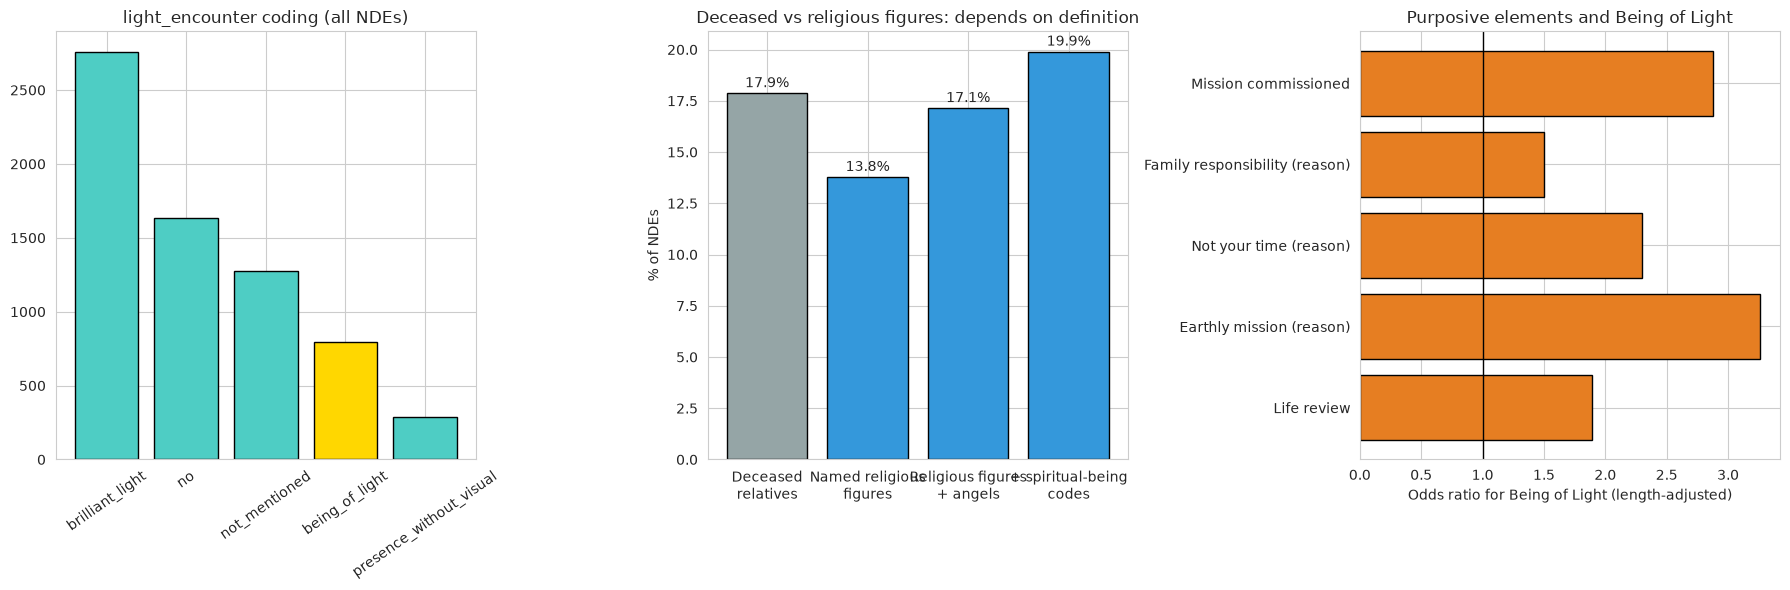

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes[0]
lc = df["light_encounter"].value_counts()
ax.bar(lc.index, lc.values, color=["#FFD700" if k == "being_of_light" else "#4ECDC4" for k in lc.index], edgecolor="black")
ax.set_title("light_encounter coding (all NDEs)"); ax.tick_params(axis="x", rotation=35)
ax = axes[1]
labels = ["Deceased\nrelatives", "Named religious\nfigures", "Religious figures\n+ angels", "+ spiritual-being\ncodes"]
vals = [df.deceased.mean()] + [x.mean() for x in definitions.values()]
ax.bar(labels, [100*v for v in vals], color=["#95a5a6", "#3498db", "#3498db", "#3498db"], edgecolor="black")
for i, v in enumerate(vals):
    ax.text(i, 100*v + 0.3, f"{100*v:.1f}%", ha="center")
ax.set_title("Deceased vs religious figures: depends on definition"); ax.set_ylabel("% of NDEs")
ax = axes[2]
ax.barh(purpose["element"], purpose["length-adj OR"], color="#e67e22", edgecolor="black")
ax.axvline(1, color="black", lw=1); ax.set_xlabel("Odds ratio for Being of Light (length-adjusted)")
ax.set_title("Purposive elements and Being of Light")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "05_cultural_paradigm_summary.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Conclusion (corrected)

| Claim tested | Corrected result | Assessment |
|---|---|---|
| "Western" Being of Light 70–80% | 11.8% of all accounts; 20.7% of accounts with any light | Claimed rate **not observed** in these archives |
| Brilliant light = impersonal | Brilliant-light accounts usually include beings (57%) and communication (67%) | Relabelling **withdrawn** |
| Deceased relatives > religious figures | 17.9% vs 13.8% (named figures) but vs 17.1–19.9% including angels | **Definition-dependent**; "nearly 2×" withdrawn |
| Nature > urban | Landscape 17.0% vs buildings 11.4% (McNemar p < 10⁻²⁰) | Supported |
| Life review 25–30% | 17.5% | Lower than claimed |
| Tunnel 34–50% | 23.7% | Lower than claimed |
| Purpose ↔ personal interaction | Mission → Being of Light OR 4.4 (adjusted 3.3) | Association supported; causal reading is interpretation |
| Boundary = hard limit | Boundary reporters report *more* content (robust to length) | Not supported (hard-limit reading) |
| Boundary = correspondence of the return decision | Boundary type ↔ agency, V ≈ 0.35, partly by category definition | Interpretation, not a test |
| Tunnel independent of boundary | OR ≈ 2.4 | **Withdrawn** — they are associated |
| Japanese profile is a scholarly artefact | No Japanese data analysed | **Not tested** |

---
**Notebook**: `05_cultural_paradigm_challenge.ipynb` · **Schema**: 2026-01-06 · **Audited**: 2026-10-05